In [206]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

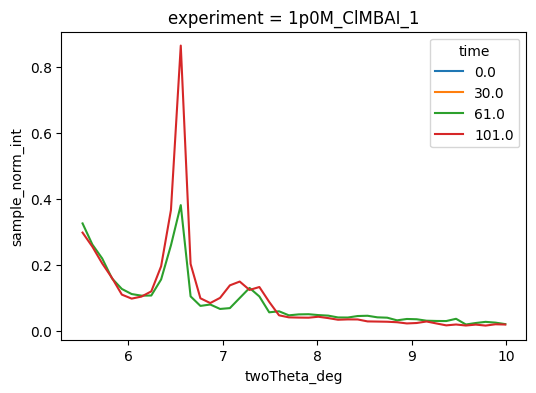

In [273]:
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc")

pdataset = pdataset.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1 = pdataset.isel(experiment=4)

fig, ax = plt.subplots(figsize=(6,4))

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 10)).sel(time=[0, 30, 60, 100], method='nearest').plot.line(x="twoTheta_deg", ax=ax)

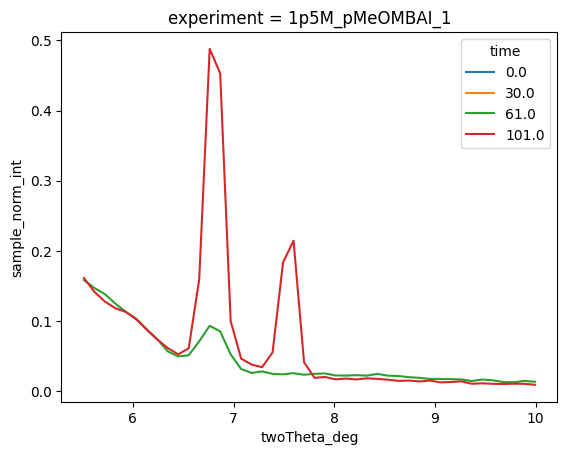

In [268]:
pdataset["sample_norm_int"] \
    .loc[dict(experiment='1p5M_pMeOMBAI_1')]\
    .sel(time=[0, 30, 60, 100], method='nearest')\
    .sel(twoTheta_deg=slice(5.5, 10))\
    .plot.line(x="twoTheta_deg")


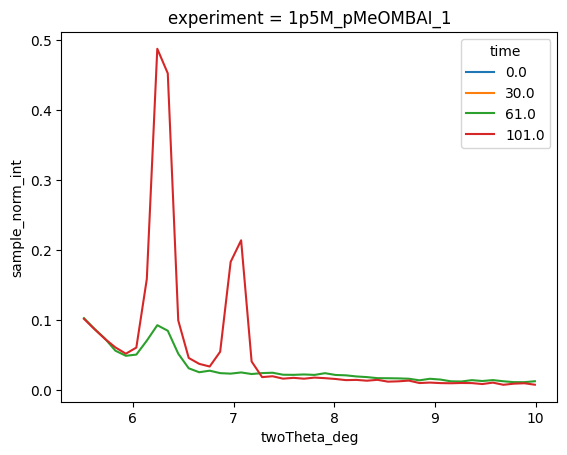

In [271]:
pdataset["sample_norm_int"] \
    .loc[dict(experiment='1p5M_pMeOMBAI_1')]\
    .shift(twoTheta_deg= -5)\
    .sel(time=[0, 30, 60, 100], method='nearest')\
    .sel(twoTheta_deg=slice(5.5, 10))\
    .plot.line(x="twoTheta_deg")


Voigt Fit Parameters for peak at 6.24°:
  Amplitude: 0.212
  Center: 6.268°
  Sigma: 0.072
  Gamma: 0.026
  Slope: -0.037
  Offset: -0.000

Voigt Fit Parameters for peak at 7.08°:
  Amplitude: 0.041
  Center: 7.053°
  Sigma: 0.163
  Gamma: 0.000
  Slope: -0.024
  Offset: -0.006

Voigt Fit Parameters for peak at 11.66°:
  Amplitude: 0.019
  Center: 11.600°
  Sigma: 0.227
  Gamma: 0.014
  Slope: -0.000
  Offset: 0.001

Voigt Fit Parameters for peak at 13.34°:
  Amplitude: 0.106
  Center: 13.286°
  Sigma: 0.090
  Gamma: 0.134
  Slope: -0.000
  Offset: -0.004



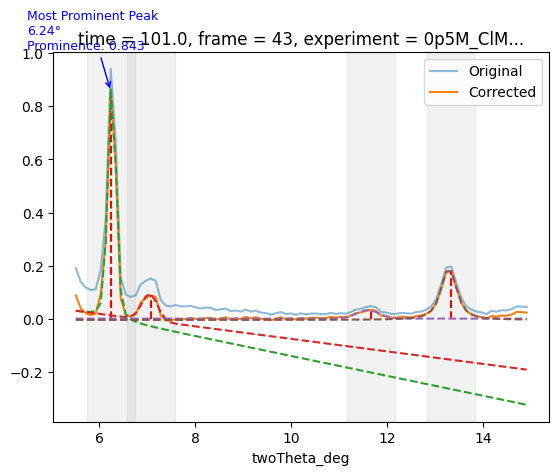

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# Import functions from analysis library
from analysis import (
    baseline_correction,
    find_peaks_in_window,
    voigt_profile_func,
    voigt_fit
)

sample_1_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 15)).dropna('time').sel(time=100, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

# fig, ax = plt.subplots(figsize=(6,4))
sample_1_da.plot(label='Original', alpha=0.5)
corrected.plot(label='Corrected')
# calc_baseline.plot(label='Baseline', linestyle=':', alpha=0.7)
plt.legend()
# plt.ylim(None, 0.15)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.01
)

plt.vlines(peaks_x, ymin=0, ymax=peaks_intensities, color='red', linestyle='--', label='Detected Peaks')

# get the most prominent peak
if properties:
    prominences = [prop['prominences'] for prop in properties]
    max_prom_idx = np.argmax(prominences)
    peak_pos = peaks_x[max_prom_idx]
    peak_intensity = peaks_intensities[max_prom_idx]
    plt.annotate(
        f"Most Prominent Peak\n{peak_pos:.2f}°\nProminence: {prominences[max_prom_idx]:.3f}",
        xy=(peak_pos, max(0.2, peak_intensity)),
        xytext=(-60,30),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        color='blue',
        arrowprops=dict(arrowstyle='->', color='blue')
    )

fitted_das = []
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0 
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        fitted_das.append(fitted_da)
    except Exception as e:
        print(f"Voigt fit failed for peak at {peak_pos:.2f}°: {e}")
        continue
    fitted_da.plot(label=f'Voigt Fit at {peak_pos:.2f}°', linestyle='--')
    # print every property as .3f
    amp, cen, sigma, gamma, slope, offset = popt
    print(
        f"Voigt Fit Parameters for peak at {peak_pos:.2f}°:\n"
        f"  Amplitude: {amp:.3f}\n"
        f"  Center: {cen:.3f}°\n"
        f"  Sigma: {sigma:.3f}\n"
        f"  Gamma: {gamma:.3f}\n"
        f"  Slope: {slope:.3f}\n"
        f"  Offset: {offset:.3f}\n"
    )
    plt.axvspan(peak_pos - 0.5, peak_pos + 0.5, color='gray', alpha=0.1)

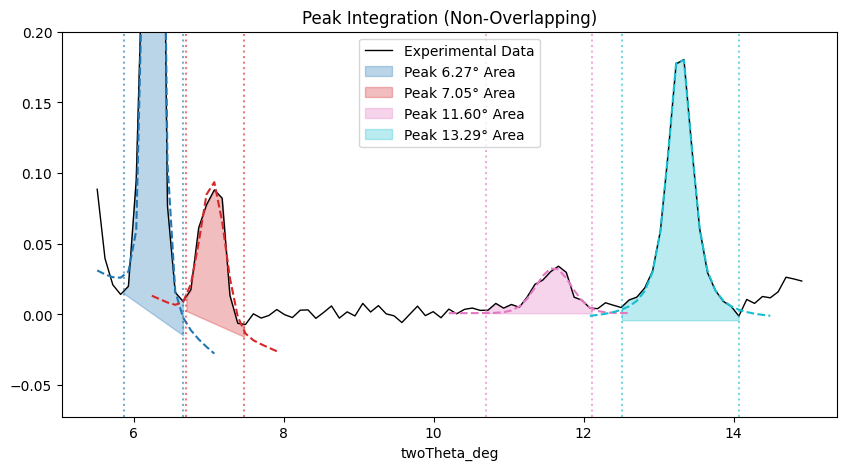

Peak Center  Area         Integration Range         Offset    
-----------------------------------------------------------------
6.268        0.20328      [5.871, 6.664]            -0.000    
7.053        0.03965      [6.703, 7.472]            -0.006    
11.600       0.02016      [10.697, 12.106]          0.001     
13.286       0.09481      [12.507, 14.066]          -0.004    


In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from analysis import calculate_peak_areas, voigt_fit, voigt_profile_func

# --- Usage (Re-run) ---

# 1. Collect fit results
collected_results = []
# print("Fitting peaks for area calculation...")
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        collected_results.append({'popt': popt, 'peak_pos': peak_pos})
    except RuntimeError:
        pass

# 2. Calculate areas (using 95% confidence)
areas_info = calculate_peak_areas(corrected, "twoTheta_deg", collected_results, confidence=0.99)

# 3. Visualization
plt.figure(figsize=(10, 5))
corrected.plot(label='Experimental Data', color='black', linewidth=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))

for i, info in enumerate(areas_info):
    l, r = info['integration_range']
    cen = info['popt'][1]
    
    if len(info['popt']) == 6:
        offset = info['popt'][5] 
        slope = info['popt'][4]
    else:
        offset = 0
        slope = 0
        
    background_func = lambda x: slope * (x - cen) + offset

    color = colors[i]
    
    # Plot boundaries
    plt.axvline(l, linestyle=':', color=color, alpha=0.6)
    plt.axvline(r, linestyle=':', color=color, alpha=0.6)

    # Re-construct subset for plotting fill
    grid_x = np.linspace(l, r, 100) # simpler for plotting
    grid_y_data = corrected.interp({"twoTheta_deg": grid_x}).values
    subset = xr.DataArray(grid_y_data, coords={"twoTheta_deg": grid_x}, dims=["twoTheta_deg"])
    
    # Shade integration area (data - background)
    bg_vals = background_func(subset.twoTheta_deg)
    
    plt.fill_between(subset.twoTheta_deg, subset, bg_vals, 
                     where=(subset > bg_vals),
                     alpha=0.3, color=color, label=f'Peak {cen:.2f}° Area')
    
    # plot the fitted Voigt profile
    subset_x_fit = corrected.sel(**{"twoTheta_deg": slice(l-0.5, r+0.5)})["twoTheta_deg"].values
    if len(subset_x_fit) > 0:
        fitted_curve = voigt_profile_func(subset_x_fit, *info['popt'])
        plt.plot(subset_x_fit, fitted_curve, linestyle='--', color=color)

plt.legend()
plt.title("Peak Integration (Non-Overlapping)")
plt.ylim(None, 0.2)
plt.show()

# 4. Print Results
print(f"{'Peak Center':<12} {'Area':<12} {'Integration Range':<25} {'Offset':<10}")
print("-" * 65)
for info in areas_info:
    l, r = info['integration_range']
    if len(info['popt']) == 6:
        off = info['popt'][5]
    else:
        off = 0
    print(f"{info['popt'][1]:<12.3f} {info['area']:<12.5f} {f'[{l:.3f}, {r:.3f}]':<25} {off:<10.3f}")

In [7]:
sample_1 = pdataset.isel(experiment=2)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(0, 300))
times = time_series_da.time.values

sample_1_da = time_series_da.sel(time=1, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.005
)

print(f"Identified peaks at positions: {peaks_x}")

Identified peaks at positions: [10.82790171 13.23131532]


In [8]:
pdataset.experiment.values

array(['0p1M_ClMBAI_1', '0p5M_ClMBAI_1', '0p5M_MBAI_1', '0p5M_pMeOMBAI_1',
       '1p0M_ClMBAI_1', '1p0M_pMeOMBAI_1', '1p5M_ClMBAI_1',
       '1p5M_pMeOMBAI_1', 'insitu_0p5M_MeOMBAI_7',
       'insitu_1p0M_ClMBAI_6re', 'insitu_1p0M_MBAI_5',
       'insitu_1p0M_MeOMBAI_6'], dtype=object)

In [274]:
import analysis
import importlib
importlib.reload(analysis)
from analysis import process_time_series
import re
from pathlib import Path

peaks_of_interest_with_phase = {
    "MBAI": [(6.9, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "ClMBAI": [(6.1, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "p?MeOMBAI": [(6.1, 0.5, "2D (002)"), (7.0, 0.5, "MeOMBAI"), (13.3, 2, "PbI2")]
}

# Apply manual shift correction for known misalignment
pdataset["sample_norm_int"].loc[dict(experiment='1p5M_pMeOMBAI_1')] = pdataset["sample_norm_int"] \
    .loc[dict(experiment='1p5M_pMeOMBAI_1')]\
    .shift(twoTheta_deg= -5)

result_dfs = {}

for experiment in pdataset.experiment.values:
    # 1. Select the time series data
    time_series_ds = pdataset.sel(experiment=experiment)
    time_series_da = time_series_ds["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(None, 300)).dropna(dim="time")

    # Defined peaks of interest: (center_position, window_size)
    for k, v in peaks_of_interest_with_phase.items():
        regexp = re.compile(f"M_{k}", re.IGNORECASE)
        if regexp.search(experiment):
            # remove phase name for processing
            peaks_of_interest = [(pos, win) for pos, win, name in v]
            break
    
    if 'peaks_of_interest' not in locals():
        print(f"No peaks of interest defined for experiment: {experiment}. Skipping.")
        continue

    # 2. Run Analysis
    # Note: visualization of shifts is now saved to disk in time_series_results/experiment_1/visualized_step/
    df_evolution, warnings = process_time_series(
        time_series_da, 
        peaks_of_interest=peaks_of_interest, 
        sample_name=time_series_ds.experiment.values,
        output_dir=str(Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\time_series_results")),
        shift_threshold=0.3, 
        perform_baseline_correction=False, 
        debug=True
    )

    # 3. Report Results
    if warnings:
        print("\n--- Significant Peak Shifts Detected ---")
        for w in warnings:
            # Limit printing if too many
            if warnings.index(w) < 10:
                print(w)
        if len(warnings) > 10:
            print(f"... and {len(warnings)-10} more.")

    result_dfs[experiment] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())




--- Significant Peak Shifts Detected ---
Time 193.0s: Peak 6.1° -> 5.742° (shift 0.358)

--- Evolution DataFrame Head ---
Peak Center  5.7       13.2  13.3  13.4
Time                                   
-5.0          NaN  0.247519   NaN   NaN
-3.0          NaN  0.243292   NaN   NaN
-1.0          NaN  0.227951   NaN   NaN
 1.0          NaN  0.217051   NaN   NaN
 3.0          NaN  0.216354   NaN   NaN

--- Evolution DataFrame Head ---
Peak Center  6.2   6.3       13.1      13.2  13.3
Time                                             
-9.0          NaN   NaN  0.229263       NaN   NaN
-7.0          NaN   NaN  0.220973       NaN   NaN
-5.0          NaN   NaN       NaN  0.239866   NaN
-3.0          NaN   NaN       NaN  0.238355   NaN
-1.0          NaN   NaN       NaN  0.245689   NaN

--- Evolution DataFrame Head ---
Peak Center  6.2   6.3       13.1      13.2  13.3
Time                                             
-9.0          NaN   NaN  0.229263       NaN   NaN
-7.0          NaN   NaN  0.22

Voigt fit failed for peak at 12.92: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.92: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.92: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.92: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.92: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for pea


--- Significant Peak Shifts Detected ---
Time 63.0s: Peak 13.3° -> 13.941° (shift 0.641)

--- Evolution DataFrame Head ---
Peak Center  6.9   7.0       13.2      13.3  13.9
Time                                             
-5.0          NaN   NaN       NaN  0.119312   NaN
-3.0          NaN   NaN       NaN  0.119686   NaN
-1.0          NaN   NaN  0.109662       NaN   NaN
 1.0          NaN   NaN  0.112451       NaN   NaN
 5.0          NaN   NaN  0.070233       NaN   NaN

--- Evolution DataFrame Head ---
Peak Center  6.2   7.0       13.2      13.3
Time                                       
-5.0          NaN   NaN  0.044351       NaN
-1.0          NaN   NaN  0.045712       NaN
 1.0          NaN   NaN       NaN  0.055736
 3.0          NaN   NaN       NaN  0.053126
 7.0          NaN   NaN       NaN  0.013427

--- Evolution DataFrame Head ---
Peak Center  6.2   7.0       13.2      13.3
Time                                       
-5.0          NaN   NaN  0.044351       NaN
-1.0          NaN 

Voigt fit failed for peak at 12.81: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Significant Peak Shifts Detected ---
Time 69.0s: Peak 6.9° -> 6.597° (shift 0.303)
Time 71.0s: Peak 6.9° -> 6.596° (shift 0.304)
Time 75.0s: Peak 6.9° -> 6.591° (shift 0.309)
Time 79.0s: Peak 6.9° -> 6.589° (shift 0.311)
Time 85.0s: Peak 6.9° -> 6.593° (shift 0.307)
Time 87.0s: Peak 6.9° -> 6.591° (shift 0.309)
Time 89.0s: Peak 6.9° -> 6.595° (shift 0.305)
Time 91.0s: Peak 6.9° -> 6.595° (shift 0.305)
Time 93.0s: Peak 6.9° -> 6.595° (shift 0.305)
Time 95.0s: Peak 6.9° -> 6.595° (shift 0.305)
... and 6 more.

--- Evolution DataFrame Head ---
Peak Center  6.6       13.1
Time                       
-3.0          NaN  0.041474
-2.0          NaN  0.039160
-1.0          NaN  0.034344
 0.0          NaN  0.031469
 1.0          NaN  0.031707

--- Evolution DataFrame Head ---
Peak Center      13.1
Time                 
-3.0         0.027546
-1.0         0.027822
 1.0         0.027310
 3.0         0.022568

--- Evolution DataFrame Head ---
Peak Center      13.1
Time                 
-3.0    

In [275]:
import pandas as pd
import re

merged_dfs = {}

for experiment, df in result_dfs.items():
    new_df = pd.DataFrame(index=df.index)
    
    # 1. Determine mapping
    mapping = []
    found_key = None
    for key, val in peaks_of_interest_with_phase.items():
        if re.search(f"M_{key}", experiment, re.IGNORECASE):
            mapping = val
            found_key = key
            break
            
    if not mapping:
        print(f"Warning: No mapping found for experiment {experiment}")
        continue
        
    print(f"Experiment: {experiment} (Matched: {found_key})")

    # 2. Rename and Merge
    for target_center, window_size, name in mapping:
        # Find columns within range
        cols_to_merge = []
        for col in df.columns:
            try:
                col_val = float(col)
                if abs(col_val - target_center) <= window_size / 2:
                    cols_to_merge.append(col)
            except ValueError:
                continue # Skip non-numeric column names if any
        
        if cols_to_merge:
            print(f"  Target '{name}' ({target_center}): Merging columns {cols_to_merge}")
            # Sum columns
            summed_series = df[cols_to_merge].sum(axis=1)
            
            # Add to new_df. If name exists (e.g. multiple targets mapping to same name), add to it.
            if name in new_df.columns:
                new_df[name] += summed_series
            else:
                new_df[name] = summed_series
        else:
            print(f"  Target '{name}' ({target_center}): No matching columns found.")
            
    merged_dfs[experiment] = new_df

Experiment: 0p1M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [5.7]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.3, 13.4]
Experiment: 0p5M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [6.2, 6.3]
  Target 'PbI2' (13.3): Merging columns [13.1, 13.2, 13.3]
Experiment: 0p5M_MBAI_1 (Matched: MBAI)
  Target '2D (002)' (6.9): Merging columns [6.9, 7.0]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.3, 13.9]
Experiment: 0p5M_pMeOMBAI_1 (Matched: p?MeOMBAI)
  Target '2D (002)' (6.1): Merging columns [6.2]
  Target 'MeOMBAI' (7.0): Merging columns [7.0]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.3]
Experiment: 1p0M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [6.5]
  Target 'PbI2' (13.3): Merging columns [13.3, 13.4]
Experiment: 1p0M_pMeOMBAI_1 (Matched: p?MeOMBAI)
  Target '2D (002)' (6.1): Merging columns [6.0, 6.1]
  Target 'MeOMBAI' (7.0): Merging columns [6.9]
  Target 'PbI2' (13.3): Merging columns [1

In [276]:
# Merge all experiments into a single DataFrame with MultiIndex columns
final_merged_df = pd.concat(merged_dfs, axis=1)

# name the top-level index as 'Experiment' and the second-level index as 'Phase'
final_merged_df.columns.names = ['experiment', 'phase']

final_merged_df

experiment 0p1M_ClMBAI_1           0p5M_ClMBAI_1           0p5M_MBAI_1  \
phase           2D (002)      PbI2      2D (002)      PbI2    2D (002)   
Time                                                                     
-5.0                 0.0  0.247519           0.0  0.239866         0.0   
-3.0                 0.0  0.243292           0.0  0.238355         0.0   
-1.0                 0.0  0.227951           0.0  0.245689         0.0   
 1.0                 0.0  0.217051           NaN       NaN         0.0   
 3.0                 0.0  0.216354           NaN       NaN         NaN   
...                  ...       ...           ...       ...         ...   
 126.0               NaN       NaN           NaN       NaN         NaN   
 156.0               NaN       NaN           NaN       NaN         NaN   
 188.0               NaN       NaN           NaN       NaN         NaN   
 238.0               NaN       NaN           NaN       NaN         NaN   
 258.0               NaN       NaN           NaN       NaN         NaN   

experiment           0p5M_pMeOMBAI_1                   1p0M_ClMBAI_1  ...  \
phase           PbI2        2D (002) MeOMBAI      PbI2      2D (002)  ...   
Time                                                                  ...   
-5.0        0.119312             0.0     0.0  0.044351           0.0  ...   
-3.0        0.119686             NaN     NaN       NaN           NaN  ...   
-1.0        0.109662             0.0     0.0  0.045712           0.0  ...   
 1.0        0.112451             0.0     0.0  0.055736           0.0  ...   
 3.0             NaN             0.0     0.0  0.053126           0.0  ...   
...              ...             ...     ...       ...           ...  ...   
 126.0           NaN             NaN     NaN       NaN           NaN  ...   
 156.0           NaN             NaN     NaN       NaN           NaN  ...   
 188.0           NaN             NaN     NaN       NaN           NaN  ...   
 238.0           NaN             NaN     NaN       NaN           NaN  ...   
 258.0           NaN             NaN     NaN       NaN           NaN  ...   

experiment 1p5M_ClMBAI_1 1p5M_pMeOMBAI_1                    \
phase               PbI2        2D (002) MeOMBAI      PbI2   
Time                                                         
-5.0                 NaN             NaN     NaN       NaN   
-3.0            0.230522             0.0     0.0  0.048765   
-1.0            0.233805             0.0     0.0  0.053401   
 1.0            0.260000             0.0     0.0  0.062736   
 3.0            0.268577             0.0     0.0  0.060966   
...                  ...             ...     ...       ...   
 126.0               NaN             NaN     NaN       NaN   
 156.0               NaN             NaN     NaN       NaN   
 188.0               NaN             NaN     NaN       NaN   
 238.0               NaN             NaN     NaN       NaN   
 258.0               NaN             NaN     NaN       NaN   

experiment insitu_0p5M_MeOMBAI_7 insitu_1p0M_ClMBAI_6re            \
phase                       PbI2               2D (002)      PbI2   
Time                                                                
-5.0                    0.026667                    0.0  0.026801   
-3.0                    0.027078                    NaN       NaN   
-1.0                    0.026632                    NaN       NaN   
 1.0                         NaN                    NaN       NaN   
 3.0                         NaN                    NaN       NaN   
...                          ...                    ...       ...   
 126.0                       NaN                    NaN       NaN   
 156.0                       NaN                    NaN       NaN   
 188.0                       NaN                    NaN       NaN   
 238.0                       NaN                    NaN       NaN   
 258.0                       NaN                    NaN       NaN   

experiment insitu_1p0M_MBAI_5           insitu_1

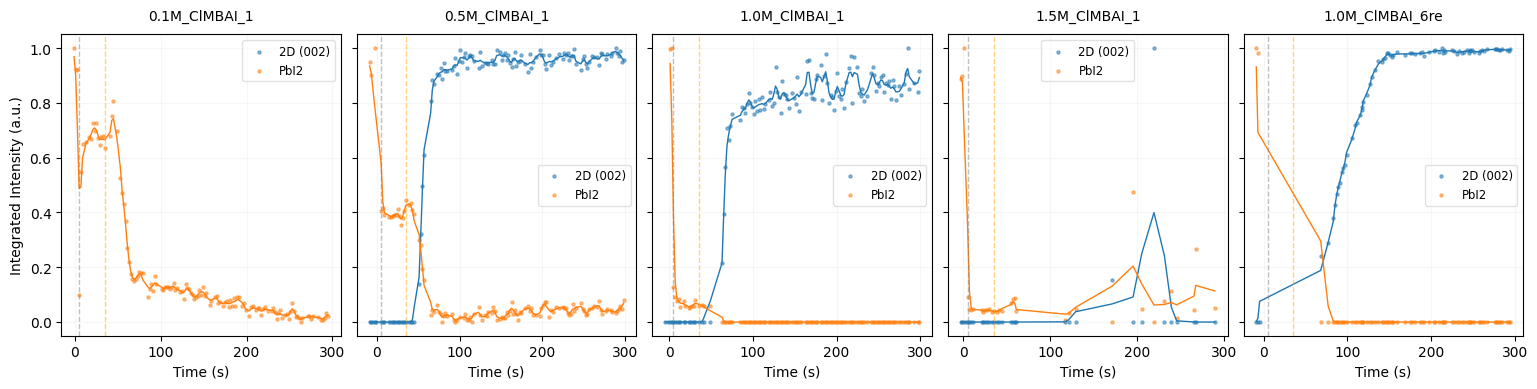

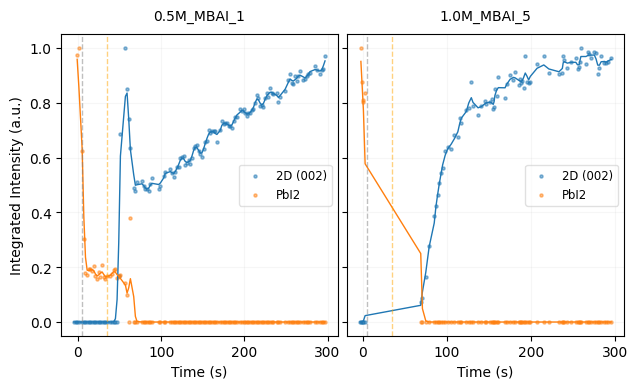

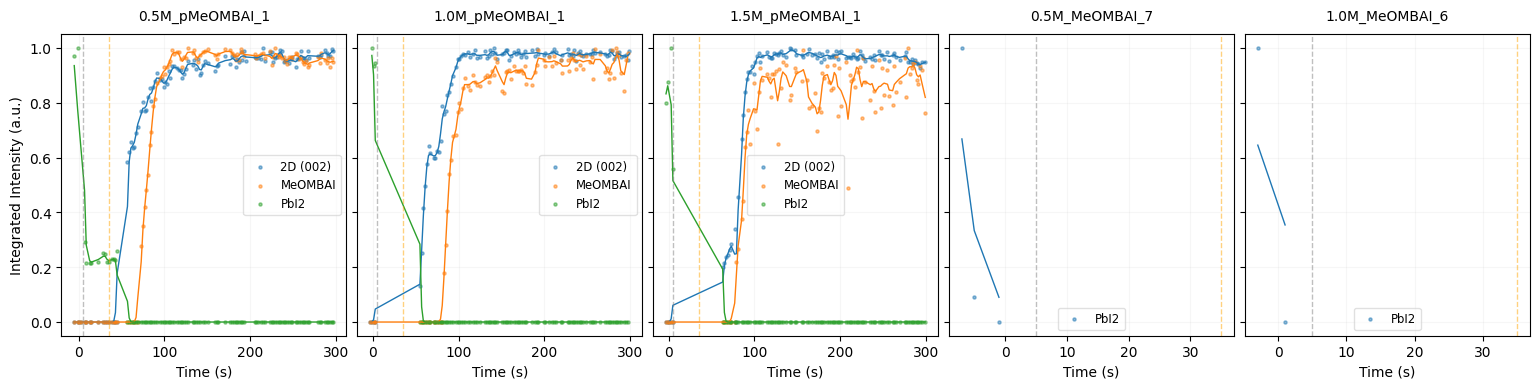

In [281]:
import matplotlib.pyplot as plt
import re
import numpy as np
from pyparsing import line
from scipy.ndimage import gaussian_filter1d

# Groups to plot together, matching the structure in giwaxs.ipynb
groups = ['ClMBAI', 'MBAI', 'p?MeOMBAI']

for group_motif in groups:
    # 1. Filter experiments matching the group
    matched_experiments = []
    # Sort keys to ensure consistent order
    for exp_name in sorted(merged_dfs.keys()):
        # The regex logic from giwaxs.ipynb
        if re.search(f"M_{group_motif}", exp_name, re.IGNORECASE):
            matched_experiments.append(exp_name)
            
    num_exps = len(matched_experiments)
    if num_exps == 0:
        continue

    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_exps, figsize=(num_exps * 3 + 0.5, 4), sharey=True)
    if num_exps == 1:
        axes = [axes]
    
    # 3. Plot each experiment
    for i, exp_name in enumerate(matched_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # remove outliers beyond 1st and 99th percentiles
            lower_bound = np.percentile(df[column], 1)
            upper_bound = np.percentile(df[column], 99)
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
            # min-max normalize
            df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
            ax.scatter(df.index, df[column], label=column, alpha=0.5, s=5)
            # use gaussian smoothing
            smooth_data = gaussian_filter1d(df[column], sigma=1)
            ax.plot(df.index, smooth_data, linewidth=1)
        
        # Formatting
        # Clean up title: replace 'p' with '.' for concentration (1p0 -> 1.0), remove prefix
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        
        ax.set_xlabel("Time (s)")
        if i == 0:
            ax.set_ylabel("Integrated Intensity (a.u.)")
        
        # Add experiment markers (Dispense and Heating)
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    plt.tight_layout(w_pad=0.02)
    plt.show()

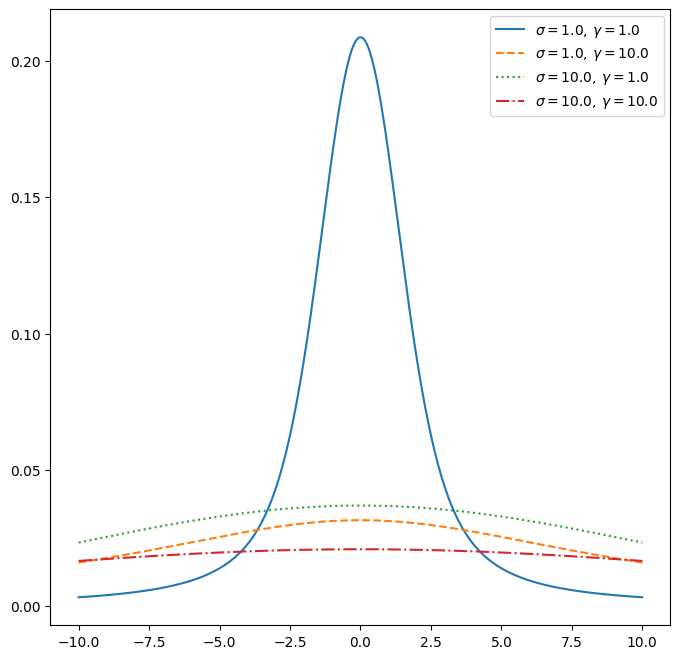

In [179]:
from scipy.special import voigt_profile
import numpy as np
import matplotlib.pyplot as plt
voigt_profile(2, 1., 1.)

fig, ax = plt.subplots(figsize=(8, 8))
x = np.linspace(-10, 10, 500)
parameters_list = [(1., 1., "solid"), (1., 10., "dashed"),
                   (10., 1., "dotted"), (10., 10., "dashdot")]
for params in parameters_list:
    sigma, gamma, linestyle = params
    voigt = voigt_profile(x, sigma, gamma)
    ax.plot(x, voigt, label=rf"$\sigma={sigma},\, \gamma={gamma}$",
            ls=linestyle)
ax.legend()
plt.show()